In [2]:
import torch
print(torch.__version__)
print("GPU available:", torch.cuda.is_available())

2.13.0+cpu
GPU available: False


Training samples: 60000
Test samples:     10000
Image shape:      torch.Size([1, 28, 28])


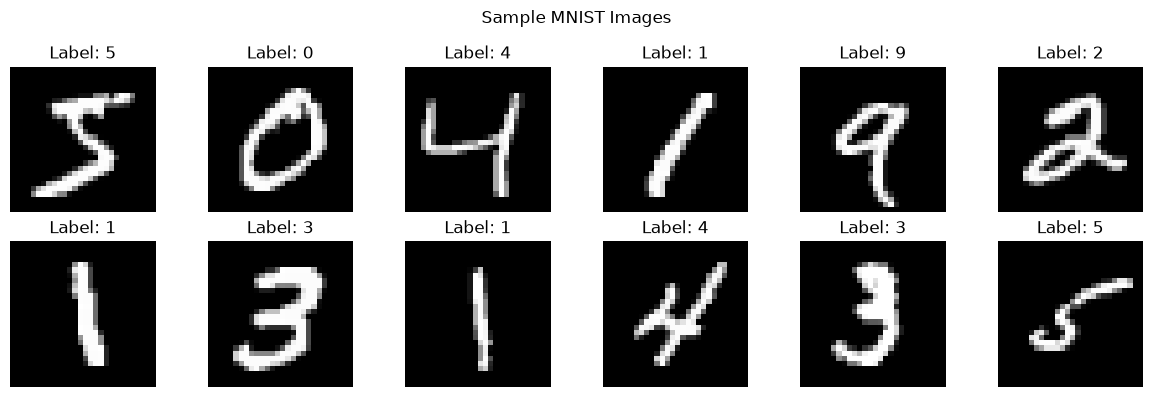

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Transform — convert image to tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),                    # PIL image → tensor (0-255 → 0.0-1.0)
    transforms.Normalize((0.1307,), (0.3081,)) # normalize with MNIST mean & std
])

# Download and load dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True,
    download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False,
    download=True, transform=transform
)

# DataLoader — batches the data
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64, shuffle=False
)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")
print(f"Image shape:      {train_dataset[0][0].shape}")

# Visualize first 12 digits
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.suptitle('Sample MNIST Images')
plt.tight_layout()
plt.show()

In [8]:
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")
print(f"Image shape:      {train_dataset[0][0].shape}")

Training samples: 60000
Test samples:     10000
Image shape:      torch.Size([1, 28, 28])


In [12]:
image, label = train_dataset[0]

print("Label:", label)
print("Tensor shape:", image.shape)
print("Min pixel value:", image.min().item())
print("Max pixel value:", image.max().item())

# See the actual numbers — the raw pixel grid
print("\nPixel values (28x28 grid):")
print(image.squeeze().numpy().round(2))

Label: 5
Tensor shape: torch.Size([1, 28, 28])
Min pixel value: -0.4242129623889923
Max pixel value: 2.821486711502075

Pixel values (28x28 grid):
[[-0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42
  -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42
  -0.42 -0.42 -0.42 -0.42]
 [-0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42
  -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42
  -0.42 -0.42 -0.42 -0.42]
 [-0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42
  -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42
  -0.42 -0.42 -0.42 -0.42]
 [-0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42
  -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42
  -0.42 -0.42 -0.42 -0.42]
 [-0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42
  -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42 -0.42
  -0.

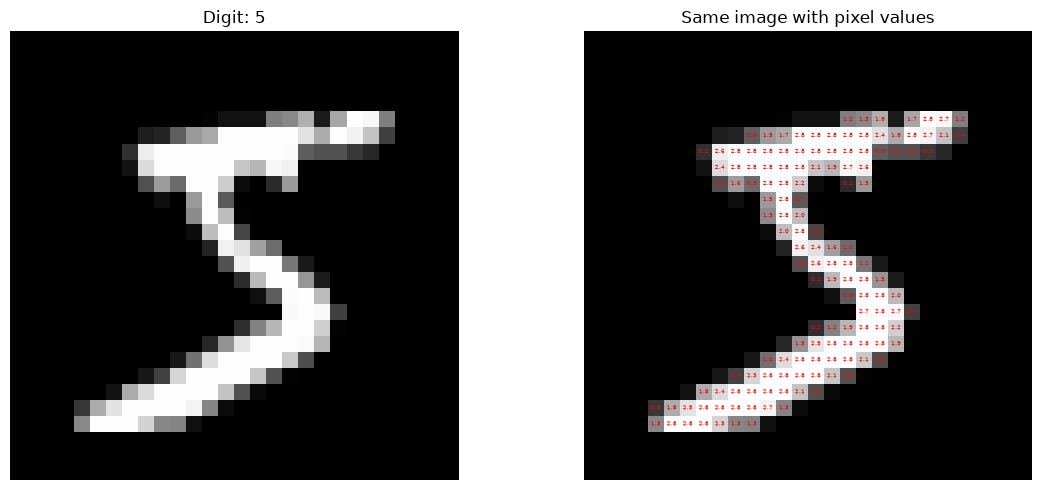

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left — normal image
axes[0].imshow(image.squeeze(), cmap='gray')
axes[0].set_title(f'Digit: {label}')
axes[0].axis('off')

# Right — pixel values visible
axes[1].imshow(image.squeeze(), cmap='gray')
for i in range(28):
    for j in range(28):
        val = image.squeeze()[i, j].item()
        if val > 0.1:   # only show non-zero pixels
            axes[1].text(j, i, f'{val:.1f}',
                        ha='center', va='center',
                        color='red', fontsize=4)
axes[1].set_title('Same image with pixel values')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [4]:
import torch.nn as nn

class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = DigitClassifier()
print(model)

DigitClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [5]:
import torch

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if batch_idx % 200 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1} complete. Average loss: {avg_loss:.4f}\n")

Epoch 1/5 | Batch 0/938 | Loss: 2.2837
Epoch 1/5 | Batch 200/938 | Loss: 0.2121
Epoch 1/5 | Batch 400/938 | Loss: 0.0842
Epoch 1/5 | Batch 600/938 | Loss: 0.1605
Epoch 1/5 | Batch 800/938 | Loss: 0.2086
Epoch 1 complete. Average loss: 0.2518

Epoch 2/5 | Batch 0/938 | Loss: 0.0269
Epoch 2/5 | Batch 200/938 | Loss: 0.1857
Epoch 2/5 | Batch 400/938 | Loss: 0.1528
Epoch 2/5 | Batch 600/938 | Loss: 0.0474
Epoch 2/5 | Batch 800/938 | Loss: 0.1721
Epoch 2 complete. Average loss: 0.1093

Epoch 3/5 | Batch 0/938 | Loss: 0.0234
Epoch 3/5 | Batch 200/938 | Loss: 0.0271
Epoch 3/5 | Batch 400/938 | Loss: 0.0147
Epoch 3/5 | Batch 600/938 | Loss: 0.0801
Epoch 3/5 | Batch 800/938 | Loss: 0.0618
Epoch 3 complete. Average loss: 0.0775

Epoch 4/5 | Batch 0/938 | Loss: 0.0681
Epoch 4/5 | Batch 200/938 | Loss: 0.0116
Epoch 4/5 | Batch 400/938 | Loss: 0.0185
Epoch 4/5 | Batch 600/938 | Loss: 0.0453
Epoch 4/5 | Batch 800/938 | Loss: 0.0476
Epoch 4 complete. Average loss: 0.0584

Epoch 5/5 | Batch 0/938 | Lo

In [6]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 97.78%


In [9]:
# save the model
torch.save(model.state_dict(), 'model.pth')
print("Model saved.")

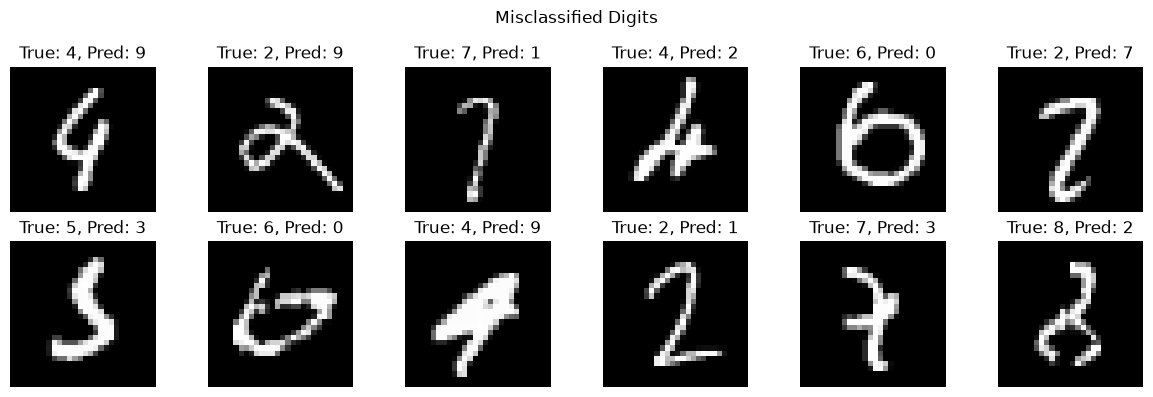

In [10]:
model.eval()
misclassified = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        wrong_mask = predictions != labels
        wrong_images = images[wrong_mask]
        wrong_true = labels[wrong_mask]
        wrong_pred = predictions[wrong_mask]

        for img, true_label, pred_label in zip(wrong_images, wrong_true, wrong_pred):
            misclassified.append((img, true_label.item(), pred_label.item()))
            if len(misclassified) >= 12:
                break
        if len(misclassified) >= 12:
            break

# Visualize
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for ax, (image, true_label, pred_label) in zip(axes.flat, misclassified):
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f"True: {true_label}, Pred: {pred_label}")
    ax.axis('off')
plt.suptitle('Misclassified Digits')
plt.tight_layout()
plt.show()